In [1]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('../IMDB Dataset.csv')

# Cleaning
def clean_review(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['cleaned_review'] = df['review'].apply(clean_review)

# Labels
y = df['sentiment'].map({'negative': 0, 'positive': 1}).values

In [2]:
from collections import Counter
import numpy as np

max_words = 20000
max_len = 200

# Build vocab
all_words = " ".join(df['cleaned_review']).split()
word_counts = Counter(all_words)
vocab = {word: i+1 for i, (word, _) in enumerate(word_counts.most_common(max_words-1))}

def encode(text):
    return [vocab.get(word, 0) for word in text.split()]

sequences = df['cleaned_review'].apply(encode)

# Padding
def pad(seq, max_len):
    if len(seq) < max_len:
        return seq + [0]*(max_len - len(seq))
    return seq[:max_len]

X = np.array([pad(seq, max_len) for seq in sequences])

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

In [4]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1,1)

X_val_tensor = torch.LongTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).reshape(-1,1)

X_test_tensor = torch.LongTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1,1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=64)

In [5]:
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, num_filters=100, kernel_sizes=[3,4,5]):
        super(CNNModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(len(kernel_sizes)*num_filters, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.embedding(x)           # (batch, seq, embed)
        x = x.permute(0, 2, 1)          # (batch, embed, seq)
        
        convs = [torch.relu(conv(x)) for conv in self.convs]
        pools = [torch.max(c, dim=2)[0] for c in convs]
        
        x = torch.cat(pools, dim=1)
        x = self.dropout(x)
        x = self.fc(x)
        
        return self.sigmoid(x)

model = CNNModel(vocab_size=max_words)

In [6]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, total = 0, 0, 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pred = (outputs >= 0.5).float()
        train_correct += (pred == y_batch).sum().item()
        total += y_batch.size(0)
    
    train_acc = 100 * train_correct / total
    
    # validation
    model.eval()
    val_loss, val_correct, total = 0, 0, 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            val_loss += loss.item()
            pred = (outputs >= 0.5).float()
            val_correct += (pred == y_batch).sum().item()
            total += y_batch.size(0)
    
    val_acc = 100 * val_correct / total
    
    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}: Train Acc {train_acc:.2f}% | Val Acc {val_acc:.2f}%")

Epoch 1: Train Acc 64.17% | Val Acc 74.73%
Epoch 2: Train Acc 75.45% | Val Acc 76.47%
Epoch 3: Train Acc 80.65% | Val Acc 83.47%
Epoch 4: Train Acc 84.43% | Val Acc 83.91%
Epoch 5: Train Acc 87.70% | Val Acc 85.12%
Epoch 6: Train Acc 90.19% | Val Acc 85.32%
Epoch 7: Train Acc 92.31% | Val Acc 85.23%
Epoch 8: Train Acc 94.30% | Val Acc 84.77%
Epoch 9: Train Acc 95.83% | Val Acc 84.93%
Epoch 10: Train Acc 96.79% | Val Acc 84.82%


In [7]:
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    preds = (outputs >= 0.5).float()
    test_accuracy = (preds == y_test_tensor).float().mean()
    
    print(f"Test Accuracy: {test_accuracy:.2%}")
    
    y_true = y_test_tensor.numpy()
    y_pred = preds.numpy()

Test Accuracy: 84.63%


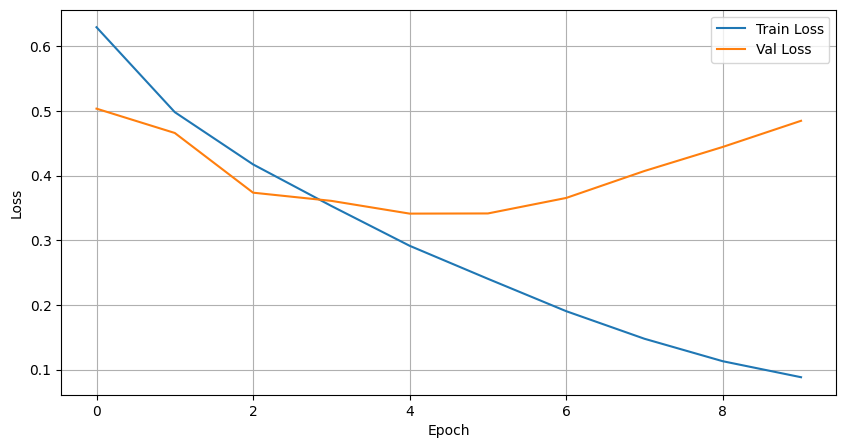

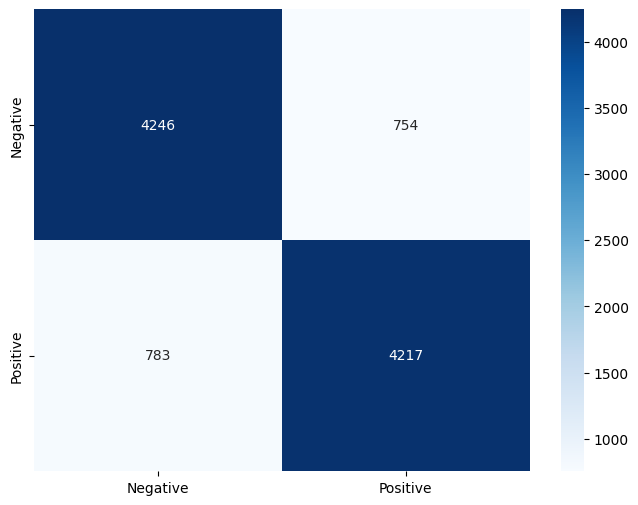

 Results discussion saved to ../results/cnn/results_discussion.txt

 ALL DONE! CNN saved correctly!


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

os.makedirs('../model', exist_ok=True)
os.makedirs('../results/cnn', exist_ok=True)

torch.save(model.state_dict(), '../model/cnn.pth')

# Loss curves
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('../results/cnn/loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.savefig('../results/cnn/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Metrics
with open('../results/cnn/metrics.txt','w') as f:
    f.write("CNN Model - Evaluation Metrics\n\n")
    f.write(f"Test Accuracy: {test_accuracy:.2%}\n\n")
    f.write(classification_report(y_true, y_pred))

# results discussion
with open('../results/cnn/results_discussion.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write("CNN - RESULTS DISCUSSION\n")
    f.write("="*50 + "\n\n")
    
    f.write(f"Model Performance:\n")
    f.write(f"- Test Accuracy: {test_accuracy:.2%}\n")
    f.write(f"- Training Accuracy (final): {train_accuracies[-1]:.2f}%\n")
    f.write(f"- Validation Accuracy (final): {val_accuracies[-1]:.2f}%\n\n")

print(" Results discussion saved to ../results/cnn/results_discussion.txt")

print("\n" + "="*50)
print(" ALL DONE! CNN saved correctly!")
print("="*50)